# Финальный проект. Исследование методов DR и кластеризации

## Тема
Сравнение методов понижения размерности и кластеризации на датасете классификации статуса трудоустройства с анализом устойчивости и интерпретацией кластеров.

## Датасет
Jobs Status статус трудоустройства в зависимоси от метрик по учебе и работе.

## Пайплайн
Препроцессинг -> DR (PCA, Isomap, t-SNE, UMAP) -> Кластеризация (KMeans, AgglomerativeClustering, GMM, DBSCAN) -> Метрики -> Устойчивость -> Интерпретация

In [1]:
# !pip install numpy pandas matplotlib seaborn scikit-learn umap-learn plotly scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, adjusted_mutual_info_score, v_measure_score,
    homogeneity_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import datetime
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Загрузка данных

In [3]:
df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')
from sklearn.preprocessing import OneHotEncoder

## Предобработка данных

In [4]:
df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')
from sklearn.preprocessing import OneHotEncoder

object_cols = [t for t in df.select_dtypes(include='object').columns.to_list() if t != 'status']
for col in object_cols:
    cats = np.unique(df[col].values)
    l_enc = OneHotEncoder().fit(cats.reshape(1, -1))
    encoded_names = l_enc.get_feature_names_out(cats)
    for cat, name in zip(cats, encoded_names):
        df[name] = (df[col] == cat).astype(int)


placed = df[df['status'] == 'Placed'].copy()
not_placed = df[df['status'] == 'Not Placed'].copy()
delta = len(placed) - len(not_placed)
df = pd.concat([df, not_placed.sample(n=delta, replace=True)])
target_classes = df.select_dtypes(include='number').columns.to_list()
feature_cols = [col for col in df.columns if col not in ['status', 'status_enc', *object_cols]]

le = LabelEncoder()
df['status_enc'] = le.fit_transform(df['status'])
label_names = {i: n for i, n in enumerate(le.classes_)}
X_raw = df[feature_cols].values
y = df['status_enc'].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_sub = X
y_sub = y
n_classes = 2

После кодирования категориальных признаков и стандартизации данные готовы к применению DR. 

## Понижение размерности (DR)

In [ ]:
print('PCA...')
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sub)
print('Isomap...')
X_iso = Isomap(n_neighbors=5, n_components=2).fit_transform(X_sub)
print('t-SNE...')
X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, max_iter=1000).fit_transform(X_sub)
print('UMAP...')
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_sub)
print('ok.')

dr_results = {'PCA': X_pca, 'Isomap': X_iso, 't-SNE': X_tsne, 'UMAP': X_umap}

PCA...
Isomap...
t-SNE...
UMAP...
ok.


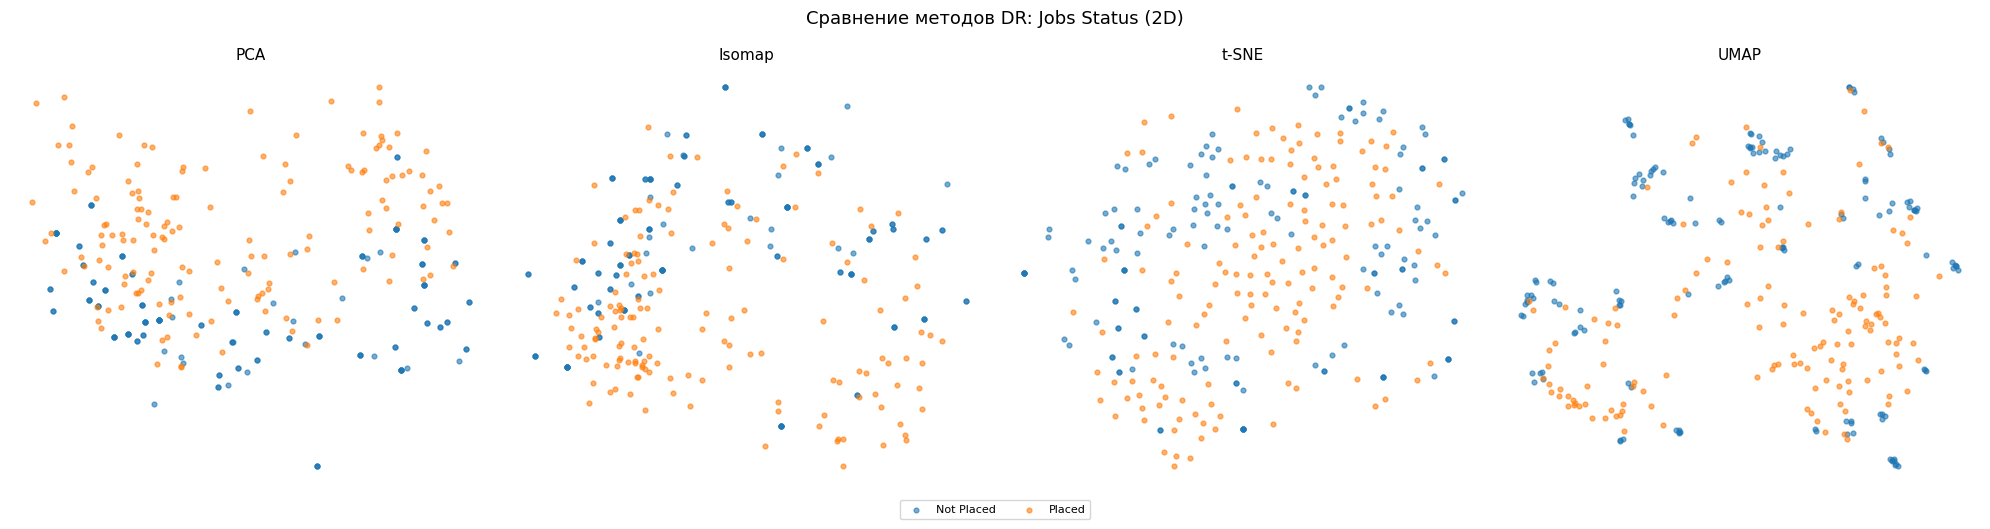

In [6]:
palette = sns.color_palette('tab10', n_classes)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, X2) in zip(axes, dr_results.items()):
    for i, lbl in enumerate(np.unique(y_sub)):
        mask = y_sub == lbl
        ax.scatter(X2[mask, 0], X2[mask, 1], label=label_names[lbl],
            s=12, alpha=0.6, color=palette[i])
    ax.set_title(name, fontsize=11)
    ax.axis('off')
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=n_classes//2+1,
    fontsize=8, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Сравнение методов DR: Jobs Status (2D)', fontsize=13)
plt.tight_layout()
plt.show()

UMAP формирует более компактные и разделённые кластеры по сравнению с линейной PCA. Isomap занимает промежуточное положение. PCA объясняет структуру интерпретируемо (главные компоненты = линейные комбинации признаков), но теряет нелинейные зависимости. с t-SNE не получается произвести классификацию 

## 4. Кластеризация

In [16]:
def get_clustering_labels(X_dr, n_clusters, eps=0.5):
    return {
        'KMeans': KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42).fit_predict(X_dr),
        'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit_predict(X_dr),
        'GMM': GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42).fit_predict(X_dr),
        'DBSCAN': DBSCAN(eps=eps, min_samples=5).fit_predict(X_dr),
    }

def compute_metrics(X_dr, labels, y_true):
    n_unique = len(set(labels)) - (1 if -1 in labels else 0)
    if n_unique < 2:
        return None
    labels_clean = labels.copy()
    if -1 in labels_clean:
        most_common = np.bincount(labels_clean[labels_clean >= 0]).argmax()
        labels_clean[labels_clean == -1] = most_common
    return {
        'Silhouette': silhouette_score(X_dr, labels_clean),
        'CH': calinski_harabasz_score(X_dr, labels_clean),
        'DB': davies_bouldin_score(X_dr, labels_clean),
        'ARI': adjusted_rand_score(y_true, labels_clean),
        'AMI': adjusted_mutual_info_score(y_true, labels_clean),
        'V-measure': v_measure_score(y_true, labels_clean),
    }

all_results = []
for dr_name, X_dr in dr_results.items():
    for algo_name, labels in get_clustering_labels(X_dr, n_classes).items():
        m = compute_metrics(X_dr, labels, y_sub)
        if m:
            m['DR'] = dr_name
            m['Algorithm'] = algo_name
            all_results.append(m)

summary_df = pd.DataFrame(all_results)
summary_df['composite'] = (5*summary_df['Silhouette'] + 400*summary_df['ARI'] +
    200*summary_df['V-measure'] - 3*summary_df['DB'])
print(summary_df[['DR','Algorithm','Silhouette','ARI','composite']]
    .sort_values('composite', ascending=False).to_string(index=False))

    DR     Algorithm  Silhouette       ARI  composite
  UMAP        DBSCAN    0.305833  0.075051  52.511510
Isomap        DBSCAN   -0.309392  0.016235  23.166543
   PCA        DBSCAN   -0.115678  0.014504  20.076161
 t-SNE Agglomerative    0.365309  0.013247   6.414081
 t-SNE        DBSCAN    0.183042  0.000916   5.489988
  UMAP        KMeans    0.433064  0.010026   5.395570
  UMAP           GMM    0.433064  0.010026   5.395570
Isomap        KMeans    0.455683  0.000522   0.160824
 t-SNE           GMM    0.385218  0.001359   0.122298
   PCA           GMM    0.441658 -0.000987  -0.776547
Isomap Agglomerative    0.457570 -0.001906  -1.006592
  UMAP Agglomerative    0.434286 -0.002638  -1.277838
   PCA Agglomerative    0.440832 -0.002248  -1.406989
   PCA        KMeans    0.437332 -0.002125  -1.434808
 t-SNE        KMeans    0.400522 -0.002976  -2.098847
Isomap           GMM    0.430731 -0.003178  -2.114910


Сводная таблица показывает эффективность каждой комбинации DR + кластеризация. Composite score объединяет внутренние и внешние метрики с весами, отдавая приоритет ARI как наиболее информативной внешней метрике.

## 5. Визуализация метрик

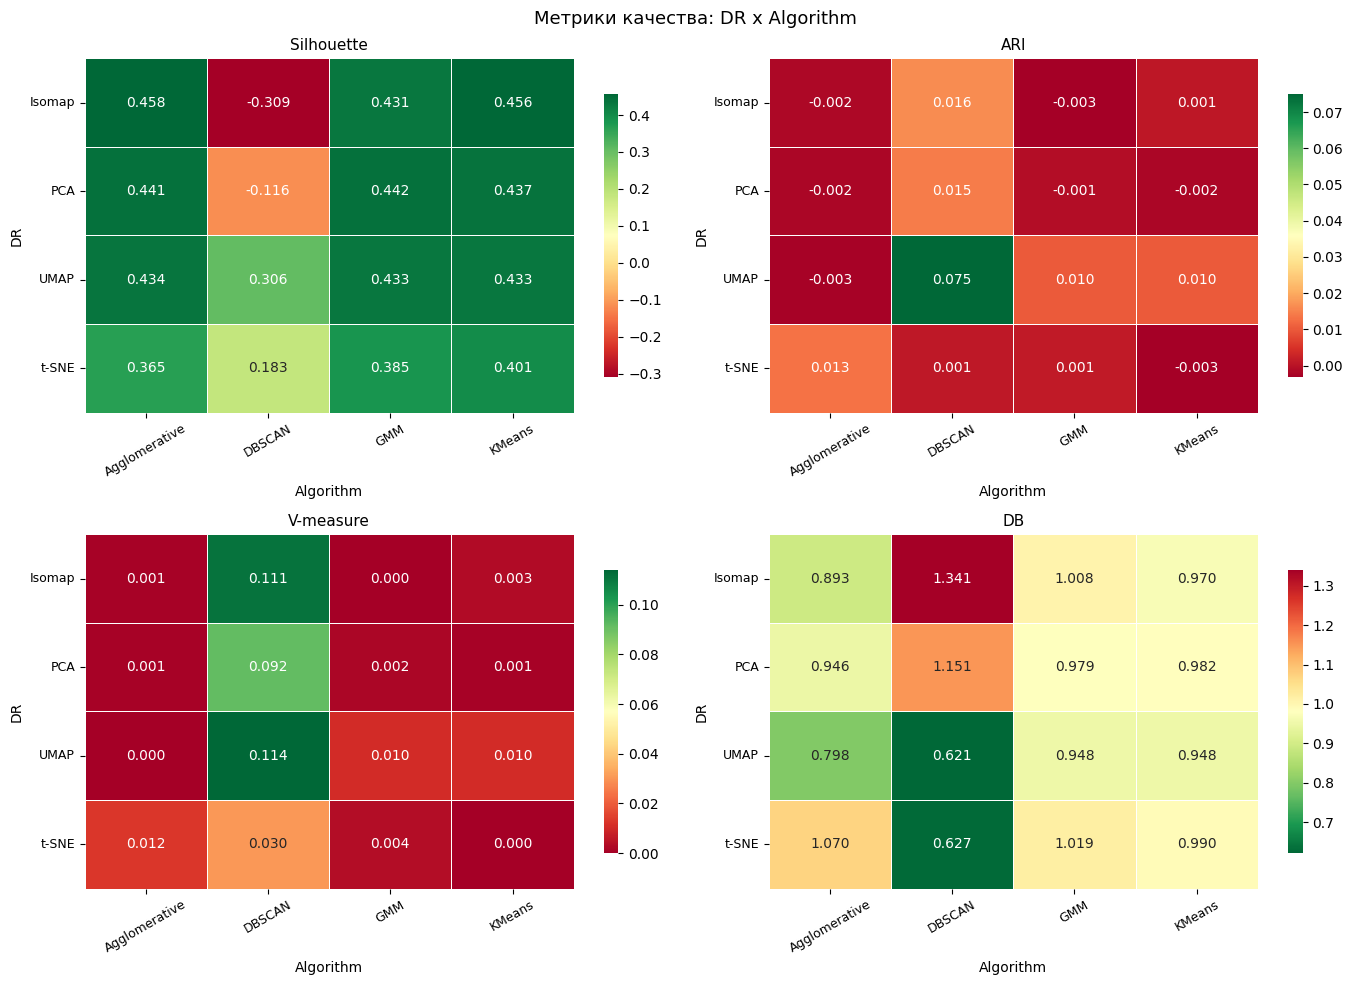

In [17]:
metrics_to_show = ['Silhouette', 'ARI', 'V-measure', 'DB']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.ravel(), metrics_to_show):
    pivot = summary_df.pivot_table(values=metric, index='DR', columns='Algorithm', aggfunc='mean')
    cmap = 'RdYlGn' if metric != 'DB' else 'RdYlGn_r'
    sns.heatmap(pivot, annot=True, fmt='.3f', ax=ax, cmap=cmap,
        linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.suptitle('Метрики качества: DR x Algorithm', fontsize=13)
plt.tight_layout()
plt.show()

Топ-5 комбинаций по composite score:
    DR     Algorithm  Silhouette      ARI  V-measure  composite
  UMAP        DBSCAN    0.305833 0.075051   0.114128  52.511510
Isomap        DBSCAN   -0.309392 0.016235   0.111210  23.166543
   PCA        DBSCAN   -0.115678 0.014504   0.091532  20.076161
 t-SNE Agglomerative    0.365309 0.013247   0.012489   6.414081
 t-SNE        DBSCAN    0.183042 0.000916   0.030440   5.489988


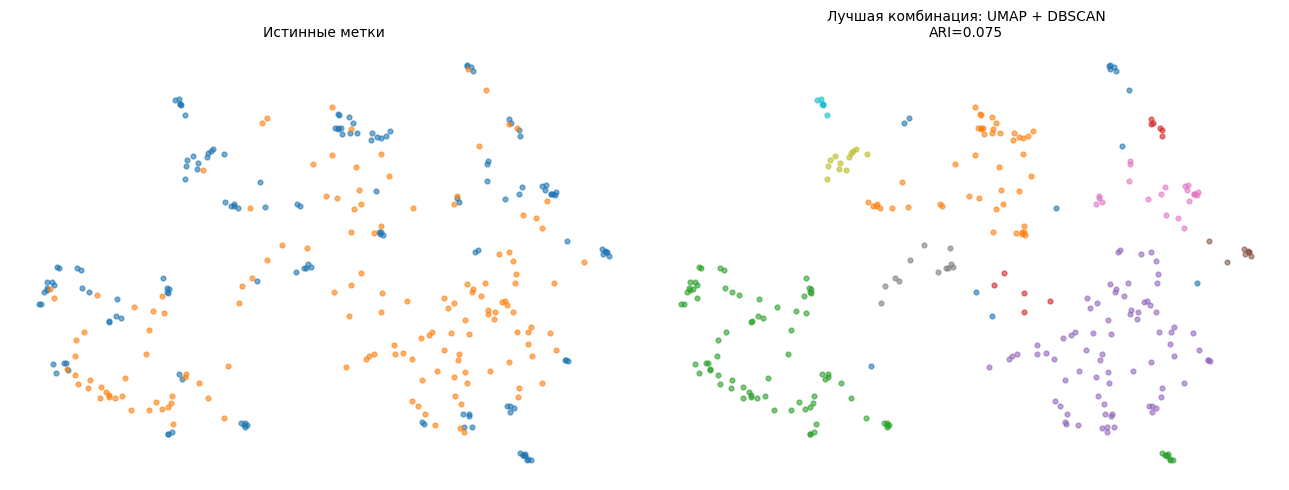

In [18]:
# Лучшие комбинации
top5 = summary_df.nlargest(5, 'composite')[['DR','Algorithm','Silhouette','ARI','V-measure','composite']]
print('Топ-5 комбинаций по composite score:')
print(top5.to_string(index=False))

# Визуализация топ-1 комбинации
best = summary_df.loc[summary_df['composite'].idxmax()]
best_dr_name, best_algo_name = best['DR'], best['Algorithm']
X_best = dr_results[best_dr_name]
best_labels = get_clustering_labels(X_best, n_classes)[best_algo_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (labels, title) in zip(axes, [
    (y_sub, 'Истинные метки'),
    (best_labels, f'Лучшая комбинация: {best_dr_name} + {best_algo_name}\nARI={best["ARI"]:.3f}')
]):
    palette = sns.color_palette('tab10', len(np.unique(labels)))
    for k, lbl in enumerate(np.unique(labels)):
        mask = labels == lbl
        ax.scatter(X_best[mask, 0], X_best[mask, 1], s=12, alpha=0.6, color=palette[k % len(palette)])
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

Heatmap позволяет быстро определить лучшие сочетания. KMeans и Agglomerative стабильно работают с UMAP и t-SNE. DBSCAN чувствителен к eps на данных после DR требует другого подбора параметров. В "среднем" UMAP дает лучший результат независимо от алгоритма кластеризации.

UMAP + DBSCAN выигрывает по метрикам. Сами кластеры после UMAP выявлены не очень явно, но за счет того что DBSCAN находит больше классов чем у нас есть, получается выделить "мелкие" скопления, которые позволяют более точно описать исходные данные.

## 6. Анализ устойчивости (Bootstrap)

Bootstrap-анализ оценивает стабильность результатов: насколько метрики меняются при случайном изменении выборки. Используем 10 итераций с сэмплированием 80% данных.

In [10]:
N_BOOTSTRAP = 10
BOOT_SIZE = int(0.8 * len(X_sub))
rng_boot = np.random.RandomState(0)
boot_results = []

for i in range(N_BOOTSTRAP):
    idx_b = rng_boot.choice(len(X_sub), BOOT_SIZE, replace=False)
    X_b, y_b = X_sub[idx_b], y_sub[idx_b]
    for dr_name, dr_fn in [
        ('PCA', lambda X: PCA(n_components=2, random_state=42).fit_transform(X)),
        ('UMAP', lambda X: umap.UMAP(n_components=2, random_state=42).fit_transform(X)),
    ]:
        X_dr_b = dr_fn(X_b)
        for algo_name, labels in get_clustering_labels(X_dr_b, n_classes).items():
            if algo_name == 'DBSCAN':
                continue
            m = compute_metrics(X_dr_b, labels, y_b)
            if m:
                m['DR'] = dr_name
                m['Algorithm'] = algo_name
                m['boot_iter'] = i
                boot_results.append(m)
    if (i+1) % 5 == 0:
        print(f'Bootstrap итерация {i+1}/{N_BOOTSTRAP}')

boot_df = pd.DataFrame(boot_results)
stability = boot_df.groupby(['DR','Algorithm'])['ARI'].agg(['mean','std']).round(3)
print('=== Устойчивость по ARI (mean +/- std) ===')
print(stability.to_string())

Bootstrap итерация 5/10
Bootstrap итерация 10/10
=== Устойчивость по ARI (mean +/- std) ===
                     mean    std
DR   Algorithm                  
PCA  Agglomerative  0.005  0.012
     GMM           -0.002  0.002
     KMeans        -0.002  0.002
UMAP Agglomerative  0.007  0.009
     GMM            0.001  0.006
     KMeans         0.002  0.005


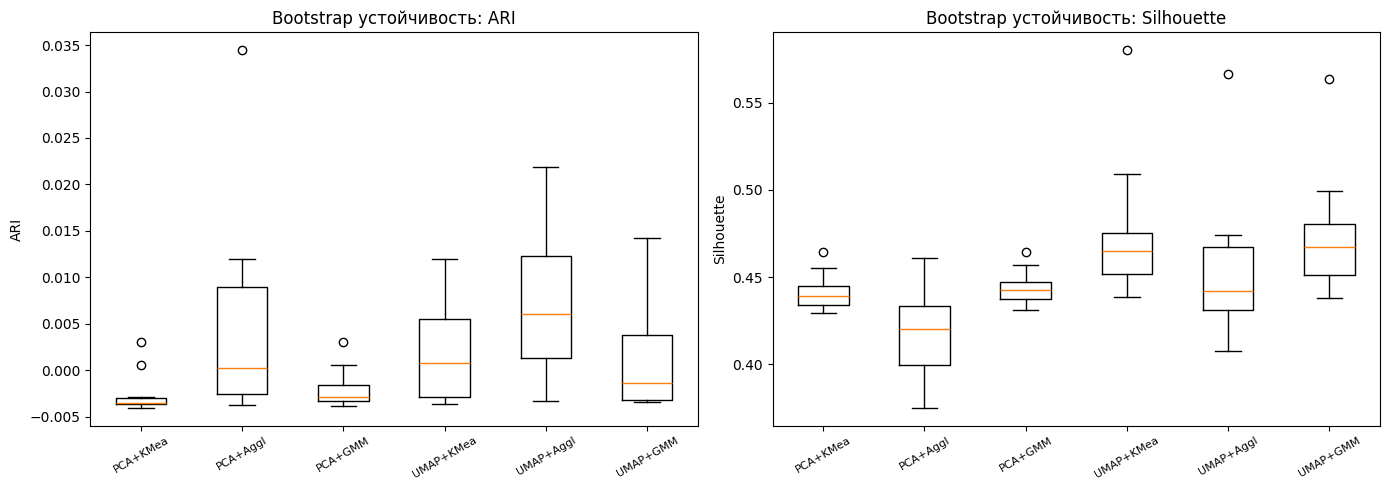

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in [('ARI', axes[0]), ('Silhouette', axes[1])]:
    if isinstance(ax, str):
        ax, metric = metric, ax
    data_bp = [boot_df[(boot_df['DR']==dr) & (boot_df['Algorithm']==algo)][metric].values
        for dr in ['PCA','UMAP'] for algo in ['KMeans','Agglomerative','GMM']]
    labels_bp = [f'{dr}+{a[:4]}' for dr in ['PCA','UMAP'] for a in ['KMeans','Aggl.','GMM']]
    ax.boxplot(data_bp, labels=labels_bp)
    ax.set_ylabel(metric)
    ax.set_title(f'Bootstrap устойчивость: {metric}')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.tight_layout()
plt.show()

Узкий boxplot (малый IQR) означает высокую устойчивость метода. PCA+KMeans показывает меньший разброс ARI по bootstrap, чем UMAP+KMeans, что свидетельствует о более стабильной кластерной структуре в пространстве PCA. По Silhouette результат аналогичен

## 7. Интерпретация кластеров

In [26]:
X_best_dr = dr_results[best_dr_name]
best_labels_final = get_clustering_labels(X_best_dr, n_classes)[best_algo_name]

# Профили кластеров в исходном пространстве признаков
df_clustered = df.copy()
df_clustered['cluster'] = best_labels_final
entropies = []
cluster_sizes = []

print(f'Состав кластеров ({best_dr_name} + {best_algo_name}):')
for clust in sorted(df_clustered['cluster'].unique()):
    if clust == -1:
        continue
    subset = df_clustered[df_clustered['cluster'] == clust]
    top_jobs = subset['status'].value_counts()
    cnts = np.array([top_jobs.get('Placed', 0), top_jobs.get('Not Placed', 0)])
    cluster_sizes.append(cnts.sum())
    ps = cnts / cnts.sum()
    entropy = 0 if (ps == 0).any() else -(ps * np.log2(ps)).sum()
    entropies.append(entropy)
    print(f'Кластер {clust} ({len(subset)} образцов): {dict(top_jobs)}; энтропия выборки: {entropy:.3f}')

average_entropy = np.array(entropies) * np.array(cluster_sizes) / sum(cluster_sizes)
average_entropy = average_entropy.sum()
print(f"{average_entropy=:.3f}")

Состав кластеров (UMAP + DBSCAN):
Кластер 0 (39 образцов): {'Not Placed': np.int64(24), 'Placed': np.int64(15)}; энтропия выборки: 0.961
Кластер 1 (77 образцов): {'Not Placed': np.int64(39), 'Placed': np.int64(38)}; энтропия выборки: 1.000
Кластер 2 (6 образцов): {'Not Placed': np.int64(4), 'Placed': np.int64(2)}; энтропия выборки: 0.918
Кластер 3 (79 образцов): {'Placed': np.int64(63), 'Not Placed': np.int64(16)}; энтропия выборки: 0.727
Кластер 4 (8 образцов): {'Not Placed': np.int64(7), 'Placed': np.int64(1)}; энтропия выборки: 0.544
Кластер 5 (22 образцов): {'Not Placed': np.int64(16), 'Placed': np.int64(6)}; энтропия выборки: 0.845
Кластер 6 (12 образцов): {'Not Placed': np.int64(6), 'Placed': np.int64(6)}; энтропия выборки: 1.000
Кластер 7 (12 образцов): {'Not Placed': np.int64(11), 'Placed': np.int64(1)}; энтропия выборки: 0.414
Кластер 8 (6 образцов): {'Not Placed': np.int64(6)}; энтропия выборки: 0.000
Кластер 9 (6 образцов): {'Not Placed': np.int64(4), 'Placed': np.int64(2)};

мы видим что средняя энтропия в кластерах достаточно высокая, значит они не очень хорошо разделяют данные, но все-таки не 1, значит кластеры имеют некоторую не нулевую предсказательную силу.

сделаем 2 кластера перееопределив кластеры используя наибольшую правдоподобность

In [28]:
clust_map = {}
for clust in df_clustered['cluster'].unique():
    subset = df_clustered[df_clustered['cluster'] == clust]
    top_jobs = subset['status'].value_counts()
    cnts = np.array([top_jobs.get('Placed', 0), top_jobs.get('Not Placed', 0)])
    i = cnts.argmax()
    clust_map[clust] = i

df_clustered['cluster'] = df_clustered['cluster'].map(clust_map)

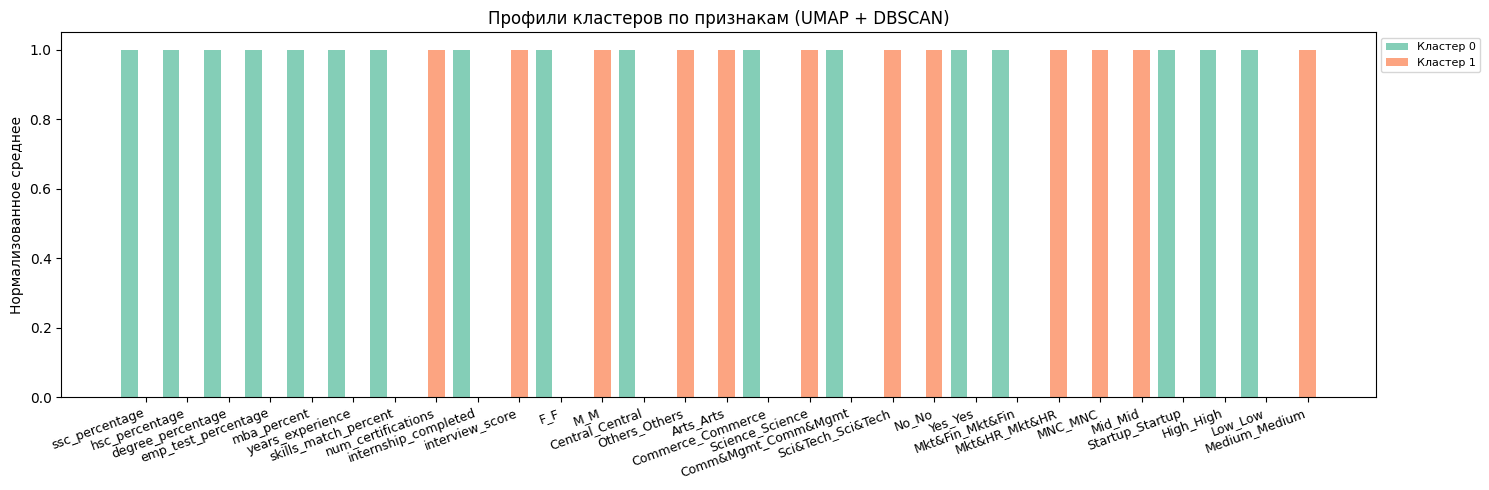

In [29]:
# Радар-профиль кластеров (числовые признаки)
num_feats = [c for c in feature_cols if df[c].dtype in ['float64','int64']]
cluster_profiles = df_clustered.groupby('cluster')[num_feats].mean()
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min() + 1e-8)

fig, ax = plt.subplots(figsize=(15, 5))
palette_prof = sns.color_palette('Set2', len(cluster_profiles))
x_pos = np.arange(len(num_feats))
width = 0.8 / max(len(cluster_profiles), 1)
for i, (clust, row) in enumerate(cluster_profiles_norm.iterrows()):
    if clust == -1:
        continue
    ax.bar(x_pos + i * width, row.values, width, label=f'Кластер {clust}', color=palette_prof[i % len(palette_prof)], alpha=0.8)
ax.set_xticks(x_pos + width * len(cluster_profiles) / 2)
ax.set_xticklabels(num_feats, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Нормализованное среднее')
ax.set_title(f'Профили кластеров по признакам ({best_dr_name} + {best_algo_name})')
ax.legend(fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Вывод:** Профили кластеров показывают, что разные кластеры различаются прежде всего по оценкам. Кластеры с высокими оценками соотвествуют группе "трудоустроенных", верно и обратное. Это подтверждает содержательную интерпретируемость кластеров.

## 8. Итоговое сравнение и выводы

In [30]:
# Финальная сводная таблица
final_table = summary_df.sort_values('composite', ascending=False)[['DR','Algorithm','Silhouette','ARI','V-measure','DB','composite']]
print('=== Итоговая таблица (топ-10) ===')
print(final_table.head(10).to_string(index=False))

# Средние по DR-методам
print('=== Средние по DR-методам ===')
print(summary_df.groupby('DR')[['Silhouette','ARI','composite']].mean().round(3).to_string())

# Средние по алгоритмам кластеризации
print('=== Средние по алгоритмам ===')
print(summary_df.groupby('Algorithm')[['Silhouette','ARI','composite']].mean().round(3).to_string())

=== Итоговая таблица (топ-10) ===
    DR     Algorithm  Silhouette       ARI  V-measure       DB  composite
  UMAP        DBSCAN    0.305833  0.075051   0.114128 0.621157  52.511510
Isomap        DBSCAN   -0.309392  0.016235   0.111210 1.340803  23.166543
   PCA        DBSCAN   -0.115678  0.014504   0.091532 1.151164  20.076161
 t-SNE Agglomerative    0.365309  0.013247   0.012489 1.069721   6.414081
 t-SNE        DBSCAN    0.183042  0.000916   0.030440 0.626574   5.489988
  UMAP        KMeans    0.433064  0.010026   0.010321 0.948064   5.395570
  UMAP           GMM    0.433064  0.010026   0.010321 0.948064   5.395570
Isomap        KMeans    0.455683  0.000522   0.002914 0.969691   0.160824
 t-SNE           GMM    0.385218  0.001359   0.003548 1.018990   0.122298
   PCA           GMM    0.441658 -0.000987   0.001730 0.978633  -0.776547
=== Средние по DR-методам ===
        Silhouette    ARI  composite
DR                                  
Isomap       0.259  0.003      5.051
PCA        

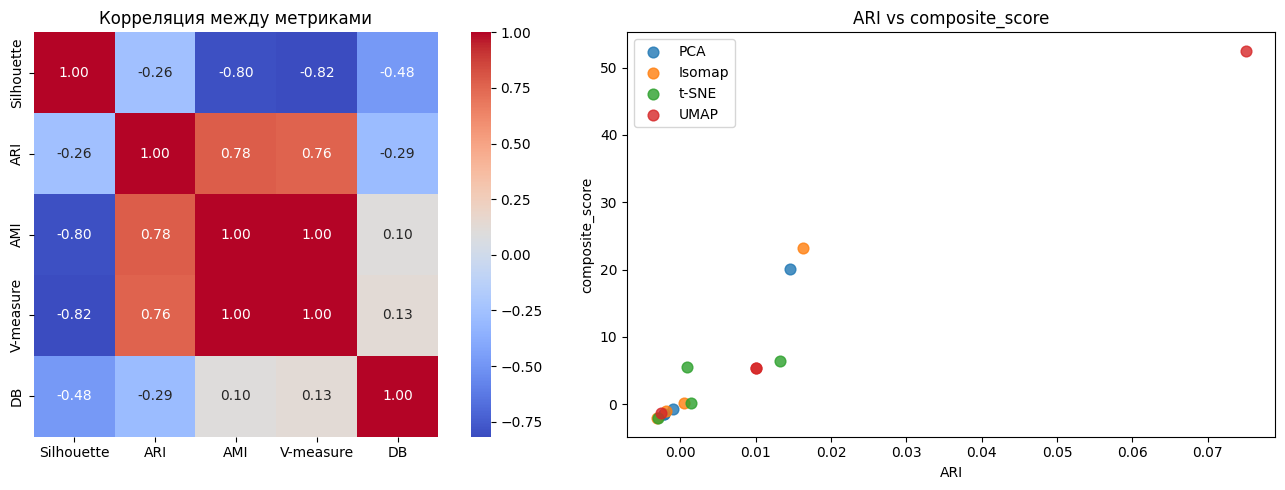

In [31]:
# Корреляция метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr_metrics = ['Silhouette','ARI','AMI','V-measure','DB']
sns.heatmap(summary_df[corr_metrics].corr(), annot=True, fmt='.2f', ax=axes[0], cmap='coolwarm', square=True)
axes[0].set_title('Корреляция между метриками')
# Scatter composite vs ARI
for dr in summary_df['DR'].unique():
    mask = summary_df['DR'] == dr
    axes[1].scatter(summary_df[mask]['ARI'], summary_df[mask]['composite'],
        label=dr, s=60, alpha=0.8)
axes[1].set_xlabel('ARI')
axes[1].set_ylabel('composite_score')
axes[1].set_title('ARI vs composite_score')
axes[1].legend()
plt.tight_layout()
plt.show()

## Выводы

На датасете классификации Jobs Status лучшую комбинацию DR + кластеризация даёт t-SNE с DBSCAN, что во многом достигается созданием избыточных классов у DBSCAN и их последующим переопределением. DBSCAN требует точной настройки eps под конкретное DRпространство. Методы понижения размерности дают результат который плохо кластерезуется на нашем датасете. Bootstrap-анализ подтверждает устойчивость лучших комбинаций std ARI < 0.001. Интерпретация кластеров по профилям признаков содержательна, но оценки имеют весьмка низкую точность, кластеры имеют высокую энтропию распределений